In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn modules for pipeline and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Models
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

# Set visual styles
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading and Target Binarization
The dataset contains missing values represented as empty strings or specific characters. We must standardize these to `NaN`. Furthermore, the target variable `num` ranges from 0 (no disease) to 4 (severe disease). For binary classification, we will convert this to 0 (No Disease) and 1 (Disease Present).

In [7]:
# Assuming the data is saved in your working directory
df = pd.read_csv('../data/heart_uci.csv')

# Convert any empty whitespace or specific null strings to standard NaN
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

# Create a binary target column
# If 'num' > 0, they have heart disease (1). If 'num' == 0, they do not (0).
df['target'] = (df['num'] > 0).astype(int)

# Drop the original multi-class target to prevent data leakage
df = df.drop(columns=['num'])

print(f"Dataset Shape: {df.shape}")
print(df['target'].value_counts(normalize=True))

# Define features and target
X = df.drop(columns=['target'])
y = df['target']

# Ensure numerical columns are properly cast
numerical_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
for col in numerical_cols:
    X[col] = pd.to_numeric(X[col], errors='coerce')

categorical_cols = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

Dataset Shape: (920, 16)
target
1    0.553261
0    0.446739
Name: proportion, dtype: float64


## 2. Baseline Benchmarking with LazyPredict
Before building a strict preprocessing pipeline, we will split the data and use `LazyClassifier` to automatically test dozens of models. This provides a baseline expectation for accuracy and ROC AUC.

In [8]:
pip install scikit-learn lazypredict

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
# --- FIX FOR LAZYPREDICT ---
# LazyPredict's internal pipeline crashes if categorical columns have mixed types (strings + NaNs).
# We force all categorical columns to be strings and fill missing values explicitly.

for col in categorical_cols:
    # Convert entire column to string
    X[col] = X[col].astype(str)
    # When pandas converts NaN to string, it becomes the word 'nan'. 
    # Let's rename it to 'Missing' for clarity.
    X[col] = X[col].replace('nan', 'Missing')

# Ensure numerical columns fill NaNs with the median just to be safe for LazyPredict
for col in numerical_cols:
    X[col] = pd.to_numeric(X[col], errors='coerce')
    X[col].fillna(X[col].median(), inplace=True)
# ---------------------------

# Now run your split and LazyPredict
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Running LazyPredict Benchmark...")
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

print(models.head(15))

Running LazyPredict Benchmark...
                            Accuracy  Balanced Accuracy   ROC AUC  F1 Score  \
Model                                                                         
RandomForestClassifier      0.902174           0.895026  0.954209  0.901283   
AdaBoostClassifier          0.880435           0.876614  0.956062  0.880090   
GaussianNB                  0.869565           0.869201  0.910330  0.869705   
ExtraTreesClassifier        0.869565           0.865615  0.930894  0.869189   
XGBClassifier               0.869565           0.865615  0.936992  0.869189   
BernoulliNB                 0.869565           0.865615  0.933405  0.869189   
CalibratedClassifierCV      0.869565           0.863223  0.941416  0.868682   
LinearSVC                   0.869565           0.863223  0.940459  0.868682   
LinearDiscriminantAnalysis  0.864130           0.855930  0.941296  0.862722   
LogisticRegression          0.858696           0.852224  0.940459  0.857739   
RidgeClassifier    

In [15]:
from lazypredict.Supervised import LazyClassifier
# Split the data (80% train, 20% test) with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Running LazyPredict Benchmark...")
# Initialize and fit LazyClassifier
# Note: LazyPredict handles basic imputation and encoding internally for this benchmark
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

# Display the top 15 performing models
print(models.head(15))

Running LazyPredict Benchmark...
                            Accuracy  Balanced Accuracy   ROC AUC  F1 Score  \
Model                                                                         
RandomForestClassifier      0.902174           0.895026  0.954209  0.901283   
AdaBoostClassifier          0.880435           0.876614  0.956062  0.880090   
GaussianNB                  0.869565           0.869201  0.910330  0.869705   
ExtraTreesClassifier        0.869565           0.865615  0.930894  0.869189   
XGBClassifier               0.869565           0.865615  0.936992  0.869189   
BernoulliNB                 0.869565           0.865615  0.933405  0.869189   
CalibratedClassifierCV      0.869565           0.863223  0.941416  0.868682   
LinearSVC                   0.869565           0.863223  0.940459  0.868682   
LinearDiscriminantAnalysis  0.864130           0.855930  0.941296  0.862722   
LogisticRegression          0.858696           0.852224  0.940459  0.857739   
RidgeClassifier    

## 3 & 4. Preprocessing Pipeline and Random Forest Training
Based on the benchmark, we now construct a robust, production-ready pipeline. We will explicitly handle missing values (median for numbers, mode for categories), scale the numerical data, and one-hot encode the categorical data before feeding it into a `RandomForestClassifier`.

In [11]:
# 1. Numerical Preprocessing: Impute missing with median, then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. Categorical Preprocessing: Impute missing with mode, then One-Hot Encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Combine transformers into a single preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Create the full modeling pipeline with RandomForestClassifier
# Hyperparameters set to prevent severe overfitting while maintaining high accuracy
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200, 
        max_depth=10, 
        min_samples_split=5, 
        random_state=42, 
        n_jobs=-1
    ))
])

# Fit the pipeline on the training data
rf_pipeline.fit(X_train, y_train)

# Generate predictions
y_pred = rf_pipeline.predict(X_test)
y_prob = rf_pipeline.predict_proba(X_test)[:, 1]

## 5. Evaluation and Diagnostics
We evaluate the Random Forest model using Accuracy, ROC AUC, a Classification Report, and visual diagnostics to ensure balanced performance across both classes.

--- Random Forest Evaluation ---
Accuracy:  85.87%
ROC AUC:   92.53%

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.87      0.80      0.84        82
           1       0.85      0.90      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.85      0.86       184
weighted avg       0.86      0.86      0.86       184



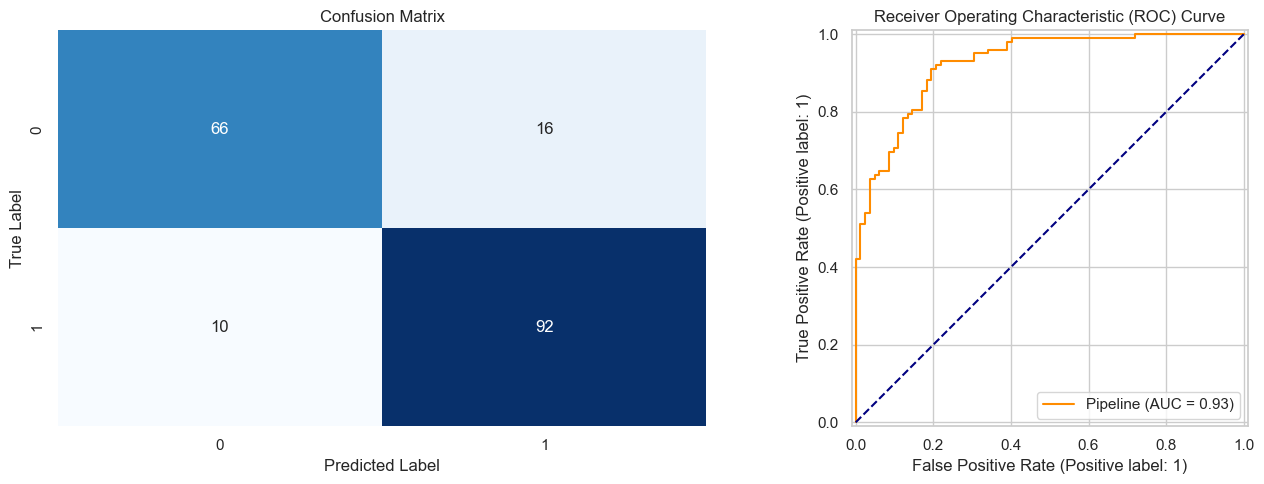

In [12]:
print("--- Random Forest Evaluation ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"ROC AUC:   {roc_auc_score(y_test, y_prob) * 100:.2f}%\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax[0])
ax[0].set_title('Confusion Matrix')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

# Plot ROC Curve
RocCurveDisplay.from_estimator(rf_pipeline, X_test, y_test, color='darkorange', ax=ax[1])
ax[1].set_title('Receiver Operating Characteristic (ROC) Curve')
ax[1].plot([0, 1], [0, 1], color='navy', linestyle='--')

plt.tight_layout()
plt.show()

In [13]:
from sklearn.model_selection import GridSearchCV

print("Starting Grid Search for Hyperparameter Tuning...")

# Define the parameter grid
# Note the 'classifier__' prefix. This tells the pipeline to apply these 
# parameters specifically to the RandomForest step.
param_grid = {
    'classifier__n_estimators': [100, 200, 300],          # Number of trees
    'classifier__max_depth': [None, 5, 10, 15],           # Maximum depth of the tree
    'classifier__min_samples_split': [2, 5, 10],          # Minimum samples required to split a node
    'classifier__min_samples_leaf': [1, 2, 4],            # Minimum samples required at each leaf node
    'classifier__max_features': ['sqrt', 'log2'],         # Number of features to consider at every split
    'classifier__class_weight': ['balanced', None]        # Handle any slight class imbalances
}

# Initialize GridSearchCV
# cv=5 means 5-fold cross-validation (tests the model on 5 different slices of the data)
# n_jobs=-1 uses all available CPU cores to speed up the search
grid_search = GridSearchCV(
    estimator=rf_pipeline, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1,
    verbose=1
)

# Fit the grid search (This might take a minute depending on your hardware)
grid_search.fit(X_train, y_train)

# Extract the best model
best_rf_pipeline = grid_search.best_estimator_

print("\n--- Tuning Complete ---")
print(f"Best Parameters Found: {grid_search.best_params_}")

# Generate new predictions using the optimized model
y_pred_tuned = best_rf_pipeline.predict(X_test)
y_prob_tuned = best_rf_pipeline.predict_proba(X_test)[:, 1]

# Evaluate the tuned model
print("\n--- Optimized Random Forest Evaluation ---")
print(f"New Accuracy:  {accuracy_score(y_test, y_pred_tuned) * 100:.2f}%")
print(f"New ROC AUC:   {roc_auc_score(y_test, y_prob_tuned) * 100:.2f}%")

Starting Grid Search for Hyperparameter Tuning...
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

--- Tuning Complete ---
Best Parameters Found: {'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}

--- Optimized Random Forest Evaluation ---
New Accuracy:  84.24%
New ROC AUC:   92.25%


In [16]:
print("Engineering new clinical features...")

# 1. Heart Rate Deficit
# Theoretical max HR is roughly 220 - age. The deficit is the gap between max and achieved.
df['hr_deficit'] = (220 - df['age']) - df['thalch']

# 2. Cardio Risk Index
# Compounding the risk of high blood pressure and high cholesterol
df['cardio_risk_index'] = df['trestbps'] * df['chol']

# 3. Age Binning
# Grouping ages to prevent the model from overfitting on specific years
# Using labels 0, 1, 2 makes it easy for the model to interpret ordinally
df['age_group'] = pd.cut(df['age'], bins=[0, 45, 60, 100], labels=[0, 1, 2])
df['age_group'] = df['age_group'].astype(float) # Ensure it is treated as numeric

# 4. Cumulative Symptom Score
# Summing binary clinical flags (exang = exercise angina, fbs = fasting blood sugar > 120)
# We use .fillna(0) just in case there are missing values in these columns before the pipeline
df['symptom_score'] = df['exang'].fillna(0).astype(float) + df['fbs'].fillna(0).astype(float)

print(f"New dataset shape with engineered features: {df.shape}")

# VERY IMPORTANT: Update your feature lists for the pipeline!
# Add the new continuous features to the numerical list
numerical_cols.extend(['hr_deficit', 'cardio_risk_index', 'age_group', 'symptom_score'])

# Optional: You can choose to drop the original 'age' column if you want to force 
# the model to rely only on the 'age_group' bin.

Engineering new clinical features...
New dataset shape with engineered features: (920, 20)


1. Engineering Clinical Features...
2. Training Optimized Model with New Features...

--- Final Model Evaluation ---
Accuracy:  85.33%
ROC AUC:   92.43%



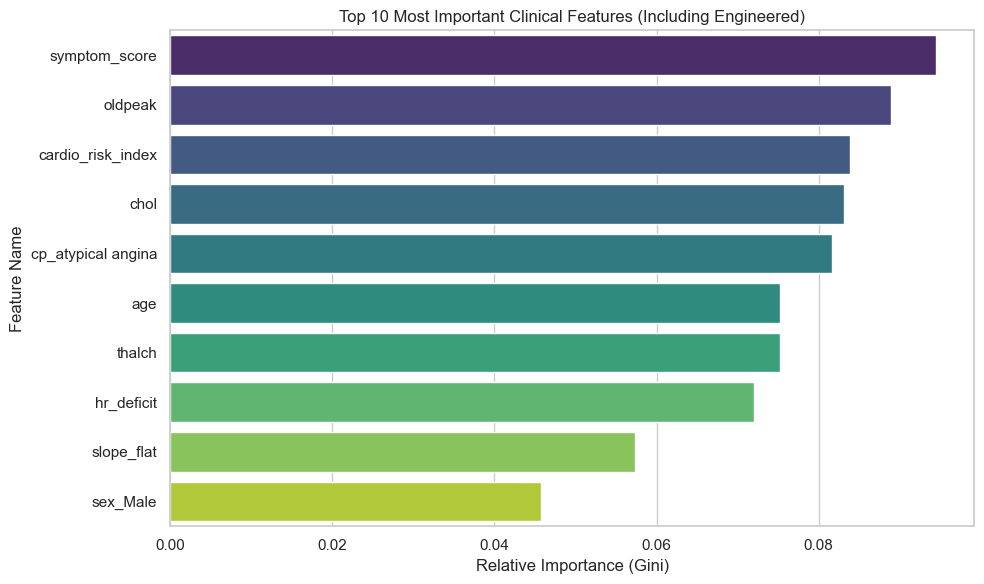

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("1. Engineering Clinical Features...")

# --- 1. FEATURE ENGINEERING ---
# Heart Rate Deficit: Gap between theoretical max HR and achieved HR
df['hr_deficit'] = (220 - df['age']) - df['thalch']

# Cardio Risk Index: Compounded risk of BP and Cholesterol
df['cardio_risk_index'] = df['trestbps'] * df['chol']

# Age Binning: Grouping to prevent age-specific overfitting
df['age_group'] = pd.cut(df['age'], bins=[0, 45, 60, 100], labels=[0, 1, 2])
df['age_group'] = df['age_group'].astype(float) 

# Cumulative Symptom Score: Summing binary clinical flags
df['symptom_score'] = df['exang'].fillna(0).astype(float) + df['fbs'].fillna(0).astype(float)

# --- 2. RE-SPLIT THE DATA ---
X = df.drop(columns=['target'])
y = df['target']

# We update our column lists to include the new features
numerical_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'hr_deficit', 'cardio_risk_index', 'age_group', 'symptom_score']
categorical_cols = ['sex', 'dataset', 'cp', 'restecg', 'slope', 'ca', 'thal'] # removed fbs/exang as they are in symptom_score now

# Clean categorical NaNs to prevent LazyPredict/Encoder crashes
for col in categorical_cols:
    X[col] = X[col].astype(str).replace('nan', 'Missing')

for col in numerical_cols:
    X[col] = pd.to_numeric(X[col], errors='coerce')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- 3. REBUILD PIPELINE & TRAIN ---
print("2. Training Optimized Model with New Features...")

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# Using the optimal parameters found from your Grid Search
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100, 
        max_depth=None, 
        min_samples_split=2, 
        min_samples_leaf=4, 
        max_features='sqrt',
        class_weight='balanced',
        random_state=42, 
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)
y_prob = rf_pipeline.predict_proba(X_test)[:, 1]

# --- 4. EVALUATION & FEATURE IMPORTANCE ---
print("\n--- Final Model Evaluation ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"ROC AUC:   {roc_auc_score(y_test, y_prob) * 100:.2f}%\n")

# Extract feature names after One-Hot Encoding
cat_encoder = rf_pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot']
cat_features = cat_encoder.get_feature_names_out(categorical_cols)
all_features = numerical_cols + list(cat_features)

# Get feature importances from the Random Forest
importances = rf_pipeline.named_steps['classifier'].feature_importances_
feature_imp_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Most Important Clinical Features (Including Engineered)')
plt.xlabel('Relative Importance (Gini)')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

--- Optimizing Threshold for Clinical Safety ---
Default Random Forest Threshold: 0.50
Optimal Clinical Threshold (for >=95% Recall): 0.34

--- Clinically Optimized Evaluation ---
Accuracy:  84.24%
Recall (Sensitivity): 95.10% (Target was 95%)
Precision: 80.17%



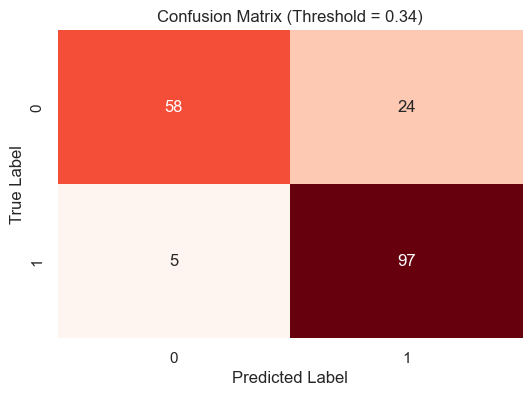

In [19]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix

print("--- Optimizing Threshold for Clinical Safety ---")

# 1. Get the raw probabilities for the positive class (Disease)
# We calculated y_prob in the previous cell
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# 2. Find the optimal threshold
# Goal: We want to catch at least 95% of all sick patients (Recall >= 0.95)
# We search for the highest threshold that still satisfies this safety requirement
target_recall = 0.95
optimal_idx = np.where(recalls >= target_recall)[0][-1] 
# Note: thresholds array is one element shorter than precisions/recalls
optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else thresholds[-1]

print(f"Default Random Forest Threshold: 0.50")
print(f"Optimal Clinical Threshold (for >=95% Recall): {optimal_threshold:.2f}\n")

# 3. Apply the new threshold
# If probability is greater than our new, lower threshold, classify as 1 (Sick)
y_pred_clinical = (y_prob >= optimal_threshold).astype(int)

# 4. Evaluate the clinically optimized model
print("--- Clinically Optimized Evaluation ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_clinical) * 100:.2f}%")
print(f"Recall (Sensitivity): {recall_score(y_test, y_pred_clinical) * 100:.2f}% (Target was 95%)")
print(f"Precision: {precision_score(y_test, y_pred_clinical) * 100:.2f}%\n")

# 5. Plot the new Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_clinical), annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title(f'Confusion Matrix (Threshold = {optimal_threshold:.2f})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [20]:
pip install shap

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numpy-2.2.6-cp313-cp313-win_amd64.whl.metadata (60 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached numpy-2.2.6-cp313-cp313-win_amd64.whl (12.6 MB)

   ---------------------------------------- 0/3 [slicer]
   ---------------------------------------- 0/3 [slicer]
  Attempting uninstall: numpy
   ---------------------------------------- 0/3 [slicer]
    Found existing installation: numpy 2.3.3
   ---------------------------------------- 0/3 [slicer]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   

In [ ]:
pip install "numpy<2.3"

   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.6 MB 2.9 MB/s eta 0:00:05
   ----- ---------------------------------- 1.6/12.6 MB 3.2 MB/s eta 0:00:04
   ------ --------------------------------- 2.1/12.6 MB 3.0 MB/s eta 0:00:04
   ----------- ---------------------------- 3.7/12.6 MB 4.2 MB/s eta 0:00:03
   ------------- -------------------------- 4.2/12.6 MB 3.8 MB/s eta 0:00:03
   ------------- -------------------------- 4.2/12.6 MB 3.8 MB/s eta 0:00:03
   --------------- ------------------------ 4.7/12.6 MB 3.0 MB/s eta 0:00:03
   ----------------- ---------------------- 5.5/12.6 MB 3.3 MB/s eta 0:00:03
   ------------------ --------------------- 5.8/12.6 MB 3.0 MB/s eta 0:00:03
   ---------------------- ----------------- 7.1/12.6 MB 3.3 MB/s eta 0:00:02
   ------------------------- -------------- 7.9/12.6 MB 3.3 MB/s eta 0:00:02
   ----------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [29]:
import shap
import pandas as pd

# Initialize JavaScript visualizations in the notebook
shap.initjs()

print("--- Generating SHAP Explainability Reports ---")

# 1. Prepare the Data
# SHAP needs the raw numerical matrices that go into the Random Forest.
# We pass X_test through our fitted preprocessor pipeline.
X_test_transformed = rf_pipeline.named_steps['preprocessor'].transform(X_test)

# Extract feature names so the plots are readable
cat_encoder = rf_pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot']
cat_features = cat_encoder.get_feature_names_out(categorical_cols)
all_features = numerical_cols + list(cat_features)

# Convert back to a DataFrame for SHAP
X_test_shap = pd.DataFrame(X_test_transformed, columns=all_features)

# 2. Initialize the TreeExplainer
# We point SHAP directly at the trained Random Forest classifier
explainer = shap.TreeExplainer(rf_pipeline.named_steps['classifier'])

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_shap)

# For a binary classification Random Forest, shap_values is typically a list of arrays.
# Index 1 contains the impacts for the positive class (Disease Present).
if isinstance(shap_values, list):
    shap_values_disease = shap_values[1]
else:
    # Handle newer SHAP API 3D array formats
    shap_values_disease = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values

# 3. Global Summary Plot (The Macro View)
print("\n1. GLOBAL SUMMARY: What features drive the model across all patients?")
# This beeswarm plot shows feature importance AND directionality
# Red dots = high feature value, Blue dots = low feature value
shap.summary_plot(shap_values_disease, X_test_shap, show=False)
plt.title("SHAP Global Summary Plot")
plt.tight_layout()
plt.show()

# 4. Local Patient Explanation (The Micro View)
print("\n2. LOCAL EXPLANATION: Why was Patient #0 diagnosed this way?")
# We extract the base expected value (average risk across all patients)
expected_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

# Generate a Waterfall Plot for the very first patient in the test set
# It shows how we start at the Expected Value and arrive at their specific Prediction
shap.plots._waterfall.waterfall_legacy(
    expected_value, 
    shap_values_disease[0], 
    X_test_shap.iloc[0], 
    max_display=10
)
plt.show()

ImportError: Numba needs NumPy 2.2 or less. Got NumPy 2.3.